# Chapter 12: Exploratory Spatial Data Analysis

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Detect spatial patterns and clusters (Moran's I)
- Distinguish between global and local spatial autocorrelation
- Interpret LISA maps for simulation initialization

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal
import esda
from esda.moran import Moran, Moran_Local
from libpysal.weights import Queen

/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Global Spatial Autocorrelation

Chapter 10 built neighborhoods without asking what they're *for*. This chapter asks the first real question a neighborhood makes possible: does a variable's value at one location tend to resemble its neighbors' values — more than random chance alone would produce?

The clearest way to build intuition is to compare a few deliberately different patterns on the exact same grid, so any difference in the result is about the *pattern*, not the geometry. A small regular grid — the same `vector_grid`-style construction Chapter 7 previewed as a DisSModel substrate — makes a clean testbed:

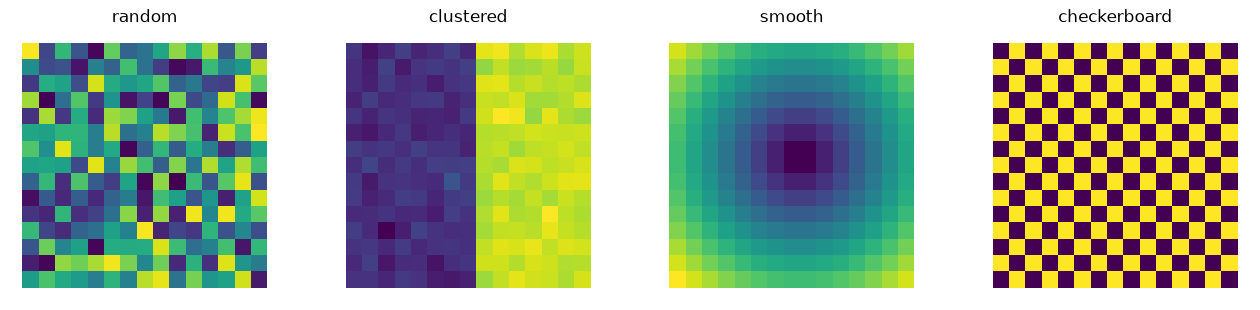

In [3]:
from shapely.geometry import box

n = 15  # 15x15 grid
cells_geom = [box(i, j, i + 1, j + 1) for j in range(n) for i in range(n)]
grid = gpd.GeoDataFrame(geometry=cells_geom)
grid["x"] = [i for j in range(n) for i in range(n)]
grid["y"] = [j for j in range(n) for i in range(n)]

np.random.seed(0)
grid["random"] = np.random.rand(len(grid))
grid["clustered"] = np.where(grid["x"] < n / 2, 0.0, 1.0) + np.random.normal(0, 0.05, len(grid))
grid["smooth"] = np.hypot(grid["x"] - n / 2, grid["y"] - n / 2)
grid["checkerboard"] = ((grid["x"] + grid["y"]) % 2).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["random", "clustered", "smooth", "checkerboard"]):
    grid.plot(column=col, ax=ax, cmap="viridis")
    ax.set_title(col)
    ax.set_axis_off()
plt.show()

Four patterns, four very different stories: `random` has no spatial logic at all; `clustered` splits the grid into one large low block and one large high block; `smooth` is a gradient radiating from the center; `checkerboard` alternates every single cell — the most extreme case of neighbors being *unlike* each other.

**Moran's I** turns "resembles its neighbors" into a single number, built directly on Chapter 10's row-standardized weights: for every cell, multiply its deviation from the mean by its **spatial lag** (the weighted average of its neighbors' deviations from the mean), sum across every cell, and normalize. The result ranges roughly from -1 (perfect dispersion — every neighbor is unlike you) to +1 (perfect clustering — every neighbor is like you), with values near 0 meaning no spatial pattern at all:

In [4]:
w = Queen.from_dataframe(grid, use_index=False)
w.transform = "r"  # row-standardized, exactly as Chapter 10 established

for col in ["random", "clustered", "smooth", "checkerboard"]:
    moran = Moran(grid[col], w)
    print(f"{col:12s}  I = {moran.I:+.3f}   p-value = {moran.p_sim:.3f}")

random        I = -0.010   p-value = 0.479
clustered     I = +0.896   p-value = 0.001
smooth        I = +0.902   p-value = 0.001
checkerboard  I = -0.052   p-value = 0.098


The four numbers tell a clear story — with one genuine surprise. `random` sits close to `0`, as expected. `clustered` and `smooth` both come out strongly positive. But `checkerboard`, the pattern deliberately built so that *every single neighbor differs*, comes out only weakly negative and not even statistically significant (`p_sim` well above 0.05) — not the clean `-1` a perfect checkerboard seems to promise.

The culprit is Chapter 10's Queen-versus-Rook distinction, reappearing in a place it's easy not to expect. **Queen** contiguity counts diagonal neighbors as neighbors — and on a checkerboard, a cell's diagonal neighbors share its *own* parity, not the opposite one. Half of every cell's Queen neighborhood (the diagonals) actually agrees with it, canceling out much of the disagreement the edge neighbors contribute. **Rook** contiguity, which only counts shared edges, has no such problem — every Rook neighbor on a checkerboard is guaranteed to be the opposite color:

In [5]:
from libpysal.weights import Rook

w_rook = Rook.from_dataframe(grid, use_index=False)
w_rook.transform = "r"

moran_queen = Moran(grid["checkerboard"], w)
moran_rook = Moran(grid["checkerboard"], w_rook)
print(f"checkerboard, Queen weights:  I = {moran_queen.I:+.3f}   p-value = {moran_queen.p_sim:.3f}")
print(f"checkerboard, Rook weights:   I = {moran_rook.I:+.3f}   p-value = {moran_rook.p_sim:.3f}")

checkerboard, Queen weights:  I = -0.052   p-value = 0.085
checkerboard, Rook weights:   I = -1.000   p-value = 0.001


That `-1.000` is as strongly negative as Moran's I can go — a perfect checkerboard measured with the contiguity definition that actually matches its structure. The lesson generalizes well beyond this one synthetic example: **the choice of spatial weights is not a neutral technicality** — it's part of the hypothesis being tested. The same data, the same statistic, two defensible definitions of "neighbor," and two answers that could not look more different.

A **Moran scatterplot** makes the same calculation visible: each cell's own value on the x-axis, its spatial lag on the y-axis. Points scattered with no trend mean `random`; points hugging an upward diagonal mean neighbors track each other (positive `I`); a downward diagonal means neighbors deliberately differ (negative `I`):

/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/spreg/diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)
/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/spreg/diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)
/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/spreg/diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)
/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/spreg/diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_

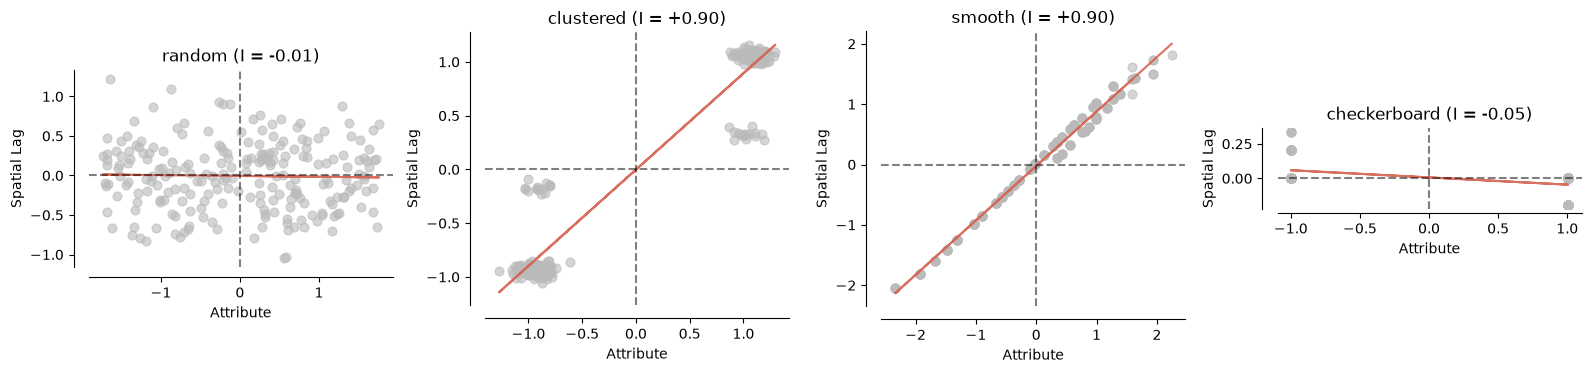

In [6]:
from splot.esda import moran_scatterplot

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["random", "clustered", "smooth", "checkerboard"]):
    moran = Moran(grid[col], w)
    moran_scatterplot(moran, ax=ax)
    ax.set_title(f"{col} (I = {moran.I:+.2f})")
plt.tight_layout()
plt.show()

## Local Indicators of Spatial Association (LISA)

A single global `I` answers "is there clustering *somewhere* on this grid" — it can't say *where*. Two grids can share nearly the same global `I` while looking completely different up close: one clustered uniformly everywhere, the other with one tight hotspot and otherwise-random noise everywhere else. **Local Indicators of Spatial Association (LISA)** — `Moran_Local` — compute one Moran's-I-like statistic *per cell*, each measuring that one cell's own relationship to its own neighbors:

In [7]:
np.random.seed(1)
lisa_clustered = Moran_Local(grid["clustered"], w)

print("First 5 cells' local Moran's I:", lisa_clustered.Is[:5])
print("First 5 cells' quadrant (1=HH, 2=LH, 3=LL, 4=HL):", lisa_clustered.q[:5])

First 5 cells' local Moran's I: [0.80978944 0.86115259 0.92866751 0.82388598 0.89995281]
First 5 cells' quadrant (1=HH, 2=LH, 3=LL, 4=HL): [3 3 3 3 3]


Every cell lands in one of four **quadrants**, named for where it sits on the Moran scatterplot: **HH** (High value, High-value neighbors — the core of a hotspot), **LL** (Low, Low — the core of a coldspot), and the two *spatial outlier* types, **HL** (a high value surrounded by low neighbors) and **LH** (the reverse). A cell's local `I` being statistically significant (`p_sim` small) is what turns a raw quadrant label into a genuine **LISA cluster** — insignificant cells are just noise sitting in one quadrant or another by chance.

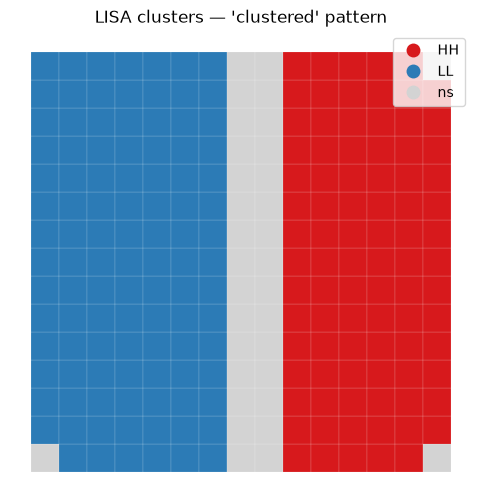

In [8]:
from splot.esda import lisa_cluster

fig, ax = plt.subplots(figsize=(6, 6))
lisa_cluster(lisa_clustered, grid, p=0.05, ax=ax)
ax.set_title("LISA clusters — 'clustered' pattern")
plt.show()

On the `clustered` grid this should draw almost exactly what you'd expect by eye — a solid HH region on the high side, a solid LL region on the low side, and little else significant. Run the same `Moran_Local` + `lisa_cluster` pair on `smooth` instead, and the *edges* of the gradient are where HL/LH outliers tend to concentrate, because a smoothly changing field still has locally "surprising" cells near its boundary of fastest change — a distinction a global `I` alone could never reveal.

LISA output is not only diagnostic — it's a legitimate way to **initialize** a spatial simulation. A land-use change model (Chapter 26) that needs a plausible starting map of "developed" versus "undeveloped" cells could seed HH cells as already-developed, LL cells as protected/undeveloped, and leave statistically insignificant cells to the model's own dynamics — turning an exploratory statistic from this chapter into a legitimate initial condition for Part III, rather than throwing the LISA analysis away once the map is drawn.

## A Real Example: Human Development in São Paulo

The grid above proves the mechanism works because its patterns are known in advance. Real data offers a different kind of proof: does the statistic find something a geographer would already expect? IDHM (Índice de Desenvolvimento Humano Municipal) for São Paulo's 645 municipalities — real IBGE boundaries, real SEADE data — is a good test case, because its geography is well documented independently of any statistic run here.

In [14]:
# Same IBGE-URL convention as Chapter 6's Maranhão example — no local copy needed
url = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "malhas_territoriais/malhas_municipais/municipio_2025/"
    "UFs/SP/SP_Municipios_2025.zip"
)
sp = gpd.read_file(url)[["CD_MUN", "NM_MUN", "geometry"]]
sp["CD_MUN"] = sp["CD_MUN"].astype(str)

# A lighter boundary is enough for a choropleth and a Queen contiguity check —
# ~50m tolerance, small enough to leave shared borders (and neighbor structure) intact
sp["geometry"] = sp.geometry.simplify(0.0005, preserve_topology=True)

idhm = pd.read_csv("idhm_sp.csv", dtype={"CD_MUN": str})
sp = sp.merge(idhm, on="CD_MUN", how="left")
sp["idhm"].isna().sum()  # confirm every municipality matched

np.int64(0)

In [15]:
w_sp = Queen.from_dataframe(sp, use_index=False)
w_sp.islands

/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:354: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 524.
  W.__init__(self, neighbors, ids=ids, **kw)


[524]

`w_sp.islands` returns a *list of indices* — one per island — not a count, so `[524]` means one island, sitting at position 524, not 524 islands. And it isn't a data error: **Ilhabela** is, literally, an island — no municipality shares a land border with it, so Queen contiguity correctly finds zero neighbors. Row-standardizing weights with an island in them needs care (its row of zeros can't be divided into shares of 1), so it's dropped from the Moran's I calculation below rather than silently mishandled.

In [16]:
sp_connected = sp.drop(w_sp.islands).reset_index(drop=True)
w_sp = Queen.from_dataframe(sp_connected, use_index=False)
w_sp.transform = "r"

moran_sp = Moran(sp_connected["idhm"].values, w_sp)
print(f"Moran's I: {moran_sp.I:.3f}   p_sim: {moran_sp.p_sim}")

Moran's I: 0.242   p_sim: 0.001


Weaker than the synthetic `clustered` or `smooth` grids (I = 0.896 and 0.902) — real data rarely comes as cleanly sorted as a constructed example — but still far from `random`'s I ≈ -0.01, and just as significant. Human development does not scatter randomly across a state's map; it just doesn't cluster as tidily as a toy grid built to demonstrate the statistic.

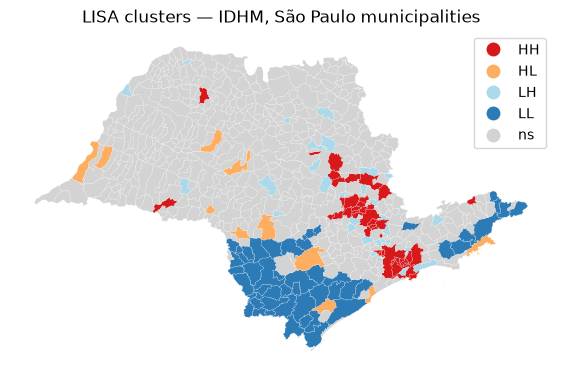

In [17]:
lisa_sp = Moran_Local(sp_connected["idhm"].values, w_sp, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
lisa_cluster(lisa_sp, sp_connected, p=0.05, ax=ax)
ax.set_title("LISA clusters — IDHM, São Paulo municipalities")
ax.set_axis_off()

In [18]:
labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
sig = lisa_sp.p_sim < 0.05
sp_connected["lisa_q"] = [labels[q] if s else "Not significant" for q, s in zip(lisa_sp.q, sig)]

print(sp_connected.loc[sp_connected["lisa_q"] == "Low-Low", "NM_MUN"].head(6).tolist())
print(sp_connected.loc[sp_connected["lisa_q"] == "High-High", "NM_MUN"].head(6).tolist())

['Ribeira', 'Cananéia', 'Guareí', 'Ribeirão Branco', 'Capão Bonito', 'Guapiara']
['São Vicente', 'Leme', 'Américo Brasiliense', 'Campinas', 'Analândia', 'São Paulo']


The Low-Low cluster is the Vale do Ribeira — São Paulo's long-documented lowest-HDI region, in the state's far south. The High-High cluster centers on greater São Paulo and Campinas. A second, smaller Low-Low patch sits inland from the north coast: Natividade da Serra (IDHM 0.65) and its neighbor Redenção da Serra, both Serra do Mar municipalities bordering the beach towns of Ubatuba and Caraguatatuba (IDHM ≈ 0.75) without sharing their tourism economy — close enough on the map to look like part of the coast, but a genuinely different, lower-scoring cluster. Neither result needed this chapter's statistics to be *discovered* — both are well known independently — which is exactly what makes them a good check: LISA recovered a real pattern instead of inventing one.

One honest limit worth stating: SEADE's IDHM only covers São Paulo, and IDHM itself is only recalculated once per Census (1991, 2000, 2010 — 2010 is what's used here, the most recent available at this granularity). A Brazil-wide comparison across all states would need a national source instead, and would say nothing more recent than 2010.

## Exercises

1. **A near-checkerboard.** Modify `checkerboard` so that 10% of cells are randomly flipped to the "wrong" value (hint: use a boolean mask and `np.random.rand(len(grid)) < 0.1`). Recompute Moran's I with Rook weights — does it stay strongly negative, or move noticeably toward zero?
2. **Does the Queen/Rook gap generalize?** Recompute `random`, `clustered`, and `smooth` with `Rook` weights instead of `Queen`. Do any of *those* three change as dramatically as `checkerboard` did, or is the diagonal-neighbor effect mostly a checkerboard-specific problem? Why might that be?
3. **LISA on `smooth`.** Run `Moran_Local` and `lisa_cluster` on the `smooth` column. Where do the HL/LH outlier cells concentrate, and does that match the *edges-of-a-gradient* intuition described above?
4. **From LISA to initial condition.** Using the LISA result on `clustered`, build a new column `seed_state` that is `1` for every statistically significant (`p_sim < 0.05`) HH cell and `0` everywhere else (hint: combine `lisa_clustered.q == 1` with `lisa_clustered.p_sim < 0.05`). Plot it — this is exactly the kind of initial condition Chapter 23's model would read in.

In [13]:
# Your code here

## Summary

### Key concepts introduced

- Moran's I: a single number, built on Chapter 10's row-standardized weights, measuring whether a variable's values resemble their spatial neighbors more than chance predicts — positive for clustering, negative for dispersion, near zero for randomness
- Permutation-based significance (`p_sim`): shuffling values across fixed geometry to check how extreme the real statistic is against a random baseline
- The Moran scatterplot: value versus spatial lag, the same relationship `I` summarizes as a single number
- LISA (`Moran_Local`) and the four quadrants — HH, LL, HL, LH — for finding *where* clustering happens, not just *whether* it does
- LISA output as a legitimate initial condition for a spatial simulation, not only a diagnostic to look at once and discard
- A real check against the synthetic grid: IDHM across São Paulo's 645 municipalities, where Moran's I and LISA recovered the Vale do Ribeira low-HDI cluster, the greater-São-Paulo high-HDI cluster, and a smaller Serra do Mar low-HDI pocket bordering the north coast — all already well documented, which is what makes them a good validation

Chapter 13 puts these same residual-autocorrelation diagnostics to work inside a regression model — once OLS residuals show the clustering this chapter just learned to detect, textbook standard errors and coefficients can no longer be trusted at face value. Chapter 15 then turns from statistics back to communication — the mapping and visualization techniques for presenting exactly the kind of pattern this chapter just learned to detect and measure.

## Further Reading

- Anselin, L. (1995). "Local Indicators of Spatial Association—LISA." *Geographical Analysis*, 27(2), 93-115 — the original LISA paper
- esda documentation, *Spatial Autocorrelation for Areal Unit Data*: <https://pysal.org/esda/>
- PySAL, *A Gentle Introduction to Spatial Autocorrelation*: <https://pysal.org/esda/notebooks/spatialautocorrelation.html>
- SEADE, *Índice de Desenvolvimento Humano Municipal (IDHM)*, São Paulo municipalities: <https://repositorio.seade.gov.br/>